In [1]:
pip install yfinance

In [4]:
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


In [5]:
# 获取昨天的日期
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365 * 5)

# 格式化为字符串形式（yfinance需要）
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# 下载江西铜业的股票数据
ticker = "600362.SS"
data = yf.download(ticker, start=start_str, end=end_str)

# 保存为CSV文件
data.to_csv('recent_stock_prices.csv')
print(f"数据已保存到 recent_stock_prices.csv（从 {start_str} 到 {end_str}）")

import pandas as pd

pf = pd.read_csv("recent_stock_prices.csv")
print(pf.head())

# 加载原始 CSV 文件
try:
    data = pd.read_csv('recent_stock_prices.csv')
    print("CSV 数据预览：")
    print(data.head())
except pd.errors.EmptyDataError:
    print("CSV 文件为空，请检查数据来源或重新下载。")
except FileNotFoundError:
    print("文件不存在，请确认文件路径是否正确。")

/tmp/ipython-input-1470216660.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed

数据已保存到 recent_stock_prices.csv（从 2020-08-15 到 2025-08-14）
        Price               Close                High                 Low  \
0      Ticker           600362.SS           600362.SS           600362.SS   
1        Date                 NaN                 NaN                 NaN   
2  2020-08-17   13.82923698425293  13.838136310858024  13.366483033712495   
3  2020-08-18  13.909329414367676  14.087311705443238  13.775842059546124   
4  2020-08-19  13.998319625854492   14.32758791321308  13.989421148139607   

                 Open     Volume  
0           600362.SS  600362.SS  
1                 NaN        NaN  
2  13.437675949180253   26164501  
3  14.016118789013014   22991661  
4  14.149604779931742   30490529  
CSV 数据预览：
        Price               Close                High                 Low  \
0      Ticker           600362.SS           600362.SS           600362.SS   
1        Date                 NaN                 NaN                 NaN   
2  2020-08-17   13.829236984

In [6]:

# 读取原始 CSV
df = pd.read_csv('recent_stock_prices.csv')

# 重命名列并删除前两行
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df = df.iloc[2:].reset_index(drop=True)

# 转换数据类型
df[['Close', 'High', 'Low', 'Open', 'Volume']] = df[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)

# 日期格式转换
df['Date'] = pd.to_datetime(df['Date'])

df.to_csv('cleaned_stock_data.csv', index=False)
print(df.head())

        Date      Close       High        Low       Open      Volume
0 2020-08-17  13.829237  13.838136  13.366483  13.437676  26164501.0
1 2020-08-18  13.909329  14.087312  13.775842  14.016119  22991661.0
2 2020-08-19  13.998320  14.327588  13.989421  14.149605  30490529.0
3 2020-08-20  13.882632  14.033917  13.775842  13.882632  15695272.0
4 2020-08-21  13.873733  14.025018  13.829237  13.829237  14360804.0


In [7]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 设置绘图风格（使用 Matplotlib 自带的样式）
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')


In [8]:
# 设置窗口大小和预测偏移
window_size = 60         # 用过去 60 天的数据预测
target_shift = 1         # 预测未来第 1 天的收盘价


In [9]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [10]:
# 加载你的数据（假设 CSV 文件中包含 Date 和 Close 列）
df = pd.read_csv('cleaned_stock_data.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# 计算 MACD 和信号线
def compute_macd(df, fast=12, slow=26, signal=9):
    df['EMA_fast'] = df['Close'].ewm(span=fast, adjust=False).mean()
    df['EMA_slow'] = df['Close'].ewm(span=slow, adjust=False).mean()
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    return df

# 计算 RSI 指标
def compute_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

# 添加技术指标
def add_technical_indicators(df):
    df = compute_macd(df)
    df = compute_rsi(df)
    df.dropna(inplace=True)
    return df

# 应用技术指标
df = add_technical_indicators(df)


In [11]:
# 添加周期性时间特征（例如：星期几、月份）
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 周一=0，周日=6
df['Month'] = df['Date'].dt.month

# 转为周期性编码（sin/cos）
df['Day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

In [12]:
features = [
    'MACD', 'MACD_signal', 'RSI',
    'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos'
]



In [13]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])


In [14]:
X, y = [], []
for i in range(window_size, len(scaled_data) - target_shift):
    X.append(scaled_data[i - window_size:i])
    y.append(scaled_data[i + target_shift][0])  # 预测收盘价

In [15]:
# 设置窗口大小和预测偏移
window_size = 50         # 用过去 50 天的数据预测
target_shift = 1         # 预测未来第 1 天的收盘价

# 选择用于训练的特征（你已经更新过了）
features = ['Close', 'MACD', 'MACD_signal', 'RSI', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos']

# 归一化处理
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

# 构建训练数据集
X, y = [], []
for i in range(window_size, len(scaled_data) - target_shift):
    X.append(scaled_data[i - window_size:i])
    y.append(scaled_data[i + target_shift][0])  # 预测收盘价

X, y = np.array(X), np.array(y)

# 划分训练集和验证集
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)


In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 构建模型函数
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# 构建模型（确保 X_train 已定义）
model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

# 回调函数（可选）
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)

# 模型训练
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
24/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1386

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.1243 - val_loss: 0.0098
Epoch 2/100
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0205

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0203 - val_loss: 0.0080
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0131 - val_loss: 0.0093
Epoch 4/100
26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0109

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0109 - val_loss: 0.0064
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0112

...

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0056 - val_loss: 0.0030
Epoch 26/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0071 - val_loss: 0.0038
Epoch 27/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0058 - val_loss: 0.0039
Epoch 28/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0053 - val_loss: 0.0032
Epoch 29/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053 - val_loss: 0.0031
Epoch 30/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0061 - val_loss: 0.0048
Epoch 31/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0056 - val_loss: 0.0035
Epoch 32/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0052 - val_loss: 0.0038
Epoch 33/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - val_loss: 0.0033
Epoch 34/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064 - val_loss: 0.0031
Epoch 35/100
22/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0060

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0059 - val_loss: 0.0028
Epoch 36/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0057 - val_loss: 0.0043
Epoch 37/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064 - val_loss: 0.0028
Epoch 38/100
23/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0051

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051 - val_loss: 0.0027
Epoch 39/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0053 - val_loss: 0.0048
Epoch 40/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0049 - val_loss: 0.0028
Epoch 41/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0051 - val_loss: 0.0030
Epoch 42/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0052 - val_loss: 0.0043
Epoch 43/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0056 - val_loss: 0.0029
Epoch 44/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0054 - val_loss: 0.0028
Epoch 45/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0054 - val_loss: 0.0036
Epoch 46/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 - val_loss: 0.0029
Epoch 47/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - val_loss: 0.0035
Epoch 48/100
22/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0055

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0053 - val_loss: 0.0025
Epoch 49/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 50/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0050 - val_loss: 0.0029
Epoch 51/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 - val_loss: 0.0044
Epoch 52/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0053 - val_loss: 0.0033
Epoch 53/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0053 - val_loss: 0.0027
Epoch 54/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 55/100
26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0045 - val_loss: 0.0024
Epoch 56/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0048 - val_loss: 0.0025
Epoch 57/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0047 - val_loss: 0.0024
Epoch 58/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0050 - val_loss: 0.0030
Epoch 59/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0048 - val_loss: 0.0029
Epoch 60/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - val_loss: 0.0024
Epoch 61/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - val_loss: 0.0039
Epoch 62/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 63/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0046 - val_loss: 0.0031
Epoch 64/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039 - val_loss: 0.0024
Epoch 65/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0041 - val_loss: 0.0028


In [18]:
# 模型预测
y_pred = model.predict(X_val)

# 反归一化（只对 'Close' 一列）
y_val_rescaled = scaler.inverse_transform(
    np.concatenate([y_val.reshape(-1, 1), np.zeros((len(y_val), len(features)-1))], axis=1)
)[:, 0]

y_pred_rescaled = scaler.inverse_transform(
    np.concatenate([y_pred, np.zeros((len(y_pred), len(features)-1))], axis=1)
)[:, 0]


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Liberatio

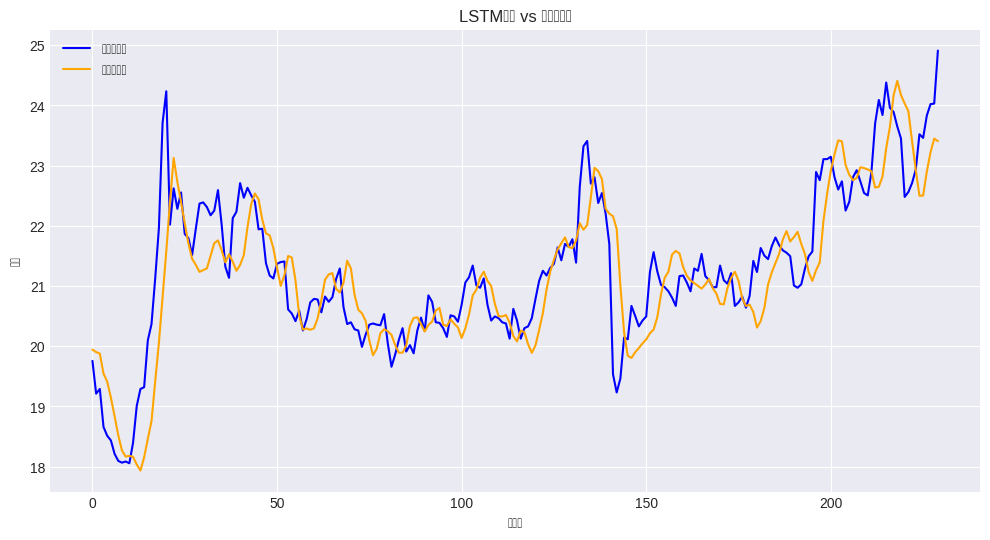

In [19]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred, title='LSTM预测 vs 实际收盘价'):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='实际收盘价', color='blue')
    plt.plot(y_pred, label='预测收盘价', color='orange')
    plt.title(title)
    plt.xlabel('时间步')
    plt.ylabel('价格')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions(y_val_rescaled, y_pred_rescaled)


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_val_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_val_rescaled, y_pred_rescaled)

print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}')


RMSE: 0.73, MAE: 0.54


In [21]:
last_sequence = scaled_data[-60:]  # 假设 lookback=60
future_preds = []

for _ in range(30):  # 预测未来30天
    input_seq = last_sequence.reshape(1, 60, len(features))
    pred = model.predict(input_seq)[0, 0]
    future_preds.append(pred)

    # 更新序列
    new_row = np.zeros((1, len(features)))
    new_row[0, 0] = pred  # 只填 'Close'，其他特征可用平均值或前值
    last_sequence = np.vstack([last_sequence[1:], new_row])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━

In [22]:
future_preds_array = np.array(future_preds).reshape(-1, 1)

# 构造虚拟特征矩阵用于反归一化（只填 'Close'）
dummy = np.zeros((len(future_preds_array), len(features)-1))
future_rescaled = scaler.inverse_transform(np.hstack([future_preds_array, dummy]))[:, 0]


In [23]:
last_date = df['Date'].iloc[-1] # Get the last date from the 'Date' column
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

In [25]:
# 安装字体
!sudo apt-get install -y fonts-wqy-zenhei
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-wqy-zenhei
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 7,472 kB of archives.
After this operation, 16.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-wqy-zenhei all 0.9.45-8 [7,472 kB]
Fetched 7,472 kB in 2s (3,842 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-wqy-zenhei.
(Reading database ... 12638

/tmp/ipython-input-3225122698.py:22: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3225122698.py:22: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3225122698.py:22: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3225122698.py:22: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3225122698.py:22: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3225122698.py:22: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3225122698.py:22: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missi

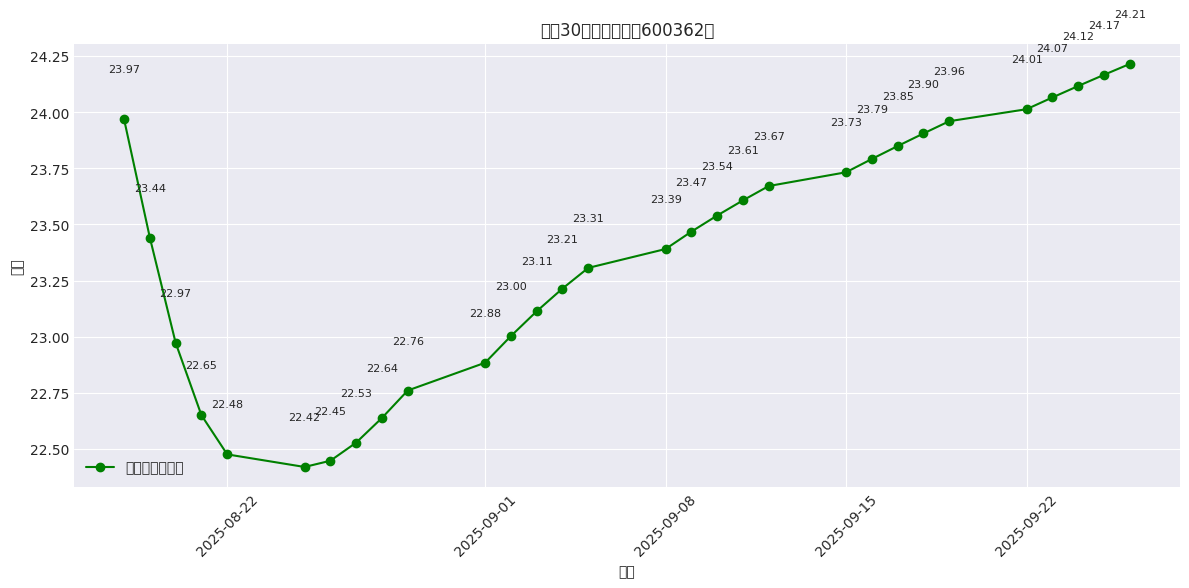

In [28]:
# 重新导入matplotlib并设置中文字体
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'WenQuanYi Zen Hei'
mpl.rcParams['axes.unicode_minus'] = False

# 重新绘制预测图
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_rescaled, label='未来预测收盘价', color='green', marker='o')
plt.title('未来30天股价预测（600362）')
plt.xlabel('日期')
plt.ylabel('价格')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)

# 添加价格标注
for x, y in zip(future_dates, future_rescaled):
    plt.text(x, y + 0.2, f'{y:.2f}', ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipython-input-555789541.py:26: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-555789541.py:26: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-555789541.py:26: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-555789541.py:26: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-555789541.py:26: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-555789541.py:26: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-555789541.py:26: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing fro

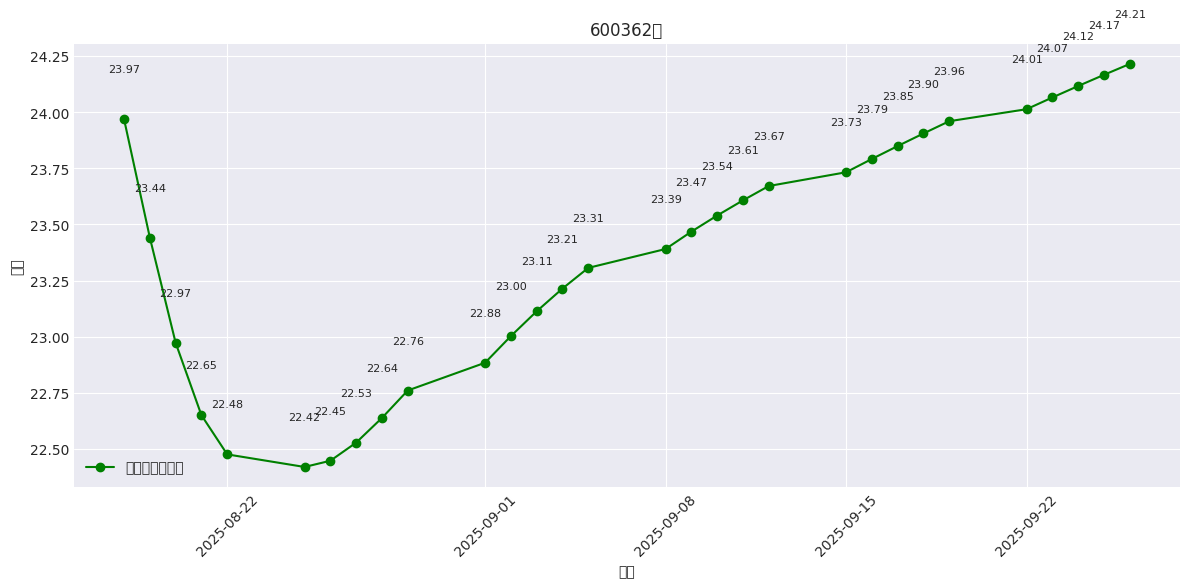

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1️⃣ 生成未来的交易日（跳过周末）
start_date = datetime.today().date() + timedelta(days=1) # Start from tomorrow's date
future_dates = pd.bdate_range(start=start_date, periods=30)

# 2️⃣ 假设你已经有预测值 future_rescaled（长度为30）
# future_rescaled = model.predict(...) 或其他方式得到的预测结果

# 3️⃣ 绘图
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_rescaled, label='未来预测收盘价', color='green', marker='o')
plt.title('600362）')
plt.xlabel('日期')
plt.ylabel('价格')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)

# 添加价格标注
for x, y in zip(future_dates, future_rescaled):
    plt.text(x, y + 0.2, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()